# CSE-CIC-IDS2018 — Compare All Models

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies, no zip/download
steps. Model list is discovered automatically from whatever `*_metrics.csv` files exist under
`Results/Models/`, so this notebook adapts to however many / whichever models
`04_Model_Training_Optuna.ipynb` and `06_MLP_Training_Optuna.ipynb` produced — no hardcoded model
names.

> **Data leakage note:** results reflect the corrected pipeline after removing the `rn` column
> (a DuckDB row-number sampling artifact that had accidentally leaked into the 30 selected model
> features in `03_Data_Preparation_for_CTGAN.ipynb`, Section 7). If you're comparing against
> older results, expect Macro F1 in particular to be lower now — that drop is the leak being
> corrected, not a regression.

## 1. Setup

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_PATH = Path(r"M:\\IDS\\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH = PROJECT_PATH / "Results"
MODELS_PATH  = RESULTS_PATH / "Models"
FIGURES_PATH = RESULTS_PATH / "Figures"
TABLES_PATH  = RESULTS_PATH / "Tables"

for p in [FIGURES_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

In [17]:
label_mapping = pd.read_csv(PROCESSED_DATA_PATH / "label_mapping.csv")
label_to_id = dict(zip(label_mapping["Class"], label_mapping["Encoded"]))
id_to_label = dict(zip(label_mapping["Encoded"], label_mapping["Class"]))
label_mapping

,Class,Encoded
0,Benign,0
1,Bot,1
2,Brute Force -Web,2
3,Brute Force -XSS,3
4,DDOS attack-HOIC,4
5,DDOS attack-LOIC-UDP,5
6,DDoS attacks-LOIC-HTTP,6
7,DoS attacks-GoldenEye,7
8,DoS attacks-Hulk,8
9,DoS attacks-SlowHTTPTest,9


## 2. Build the Model Comparison Table

Discovers every trained model's metrics file rather than assuming a fixed list.

In [18]:
metrics_files = sorted(MODELS_PATH.glob("*_metrics.csv"))
print(f"Found {len(metrics_files)} model metrics files:")
for f in metrics_files:
    print(" -", f.name)

comparison = pd.concat(
    [pd.read_csv(f) for f in metrics_files], ignore_index=True
).sort_values("Macro F1", ascending=False).reset_index(drop=True)

comparison.to_csv(TABLES_PATH / "model_comparison.csv", index=False)
comparison

Found 4 model metrics files:
 - HistGradientBoosting_Tuned_metrics.csv
 - MLP_Tuned_metrics.csv
 - RandomForest_Tuned_metrics.csv
 - XGBoost_Tuned_metrics.csv


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Prediction Time (s)
0,HistGradientBoosting_Tuned,0.980299,0.878687,0.866418,0.862697,0.982222,25.870349,6.643455
1,XGBoost_Tuned,0.985870,0.858577,0.847144,0.842936,0.984632,114.830143,2.424914
2,RandomForest_Tuned,0.899091,0.798467,0.861016,0.808213,0.936330,53.981189,4.665916
3,MLP_Tuned,0.981456,0.752465,0.812275,0.737305,0.981138,9211.981590,46.592170


In [19]:
import os

print("Metrics file freshness check -- confirm these are all post-rn-fix runs:")
for f in metrics_files:
    print(f.name, "-- last modified:", pd.Timestamp(os.path.getmtime(f), unit="s"))

Metrics file freshness check -- confirm these are all post-rn-fix runs:
HistGradientBoosting_Tuned_metrics.csv -- last modified: 2026-07-24 14:16:41.570921183
MLP_Tuned_metrics.csv -- last modified: 2026-07-26 08:53:58.084372044
RandomForest_Tuned_metrics.csv -- last modified: 2026-07-24 14:17:42.140927315
XGBoost_Tuned_metrics.csv -- last modified: 2026-07-24 14:19:43.238545895


## 3. Accuracy & Macro F1 Comparison

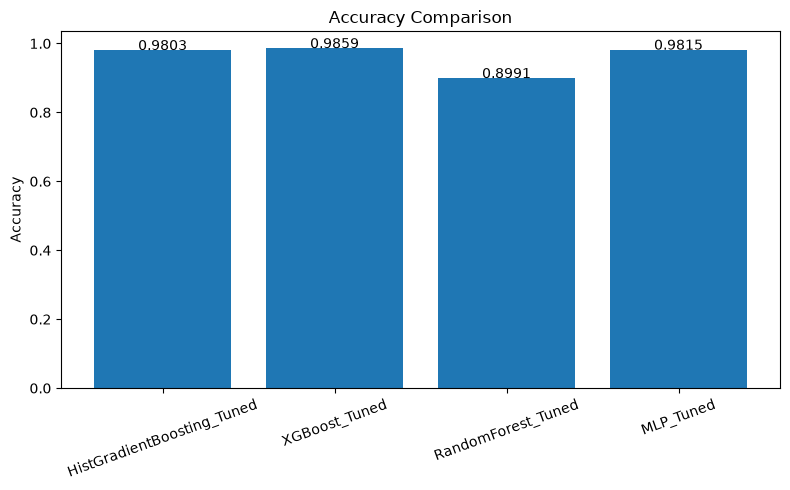

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v + 0.0005, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "accuracy_comparison.png", dpi=200)
plt.show()

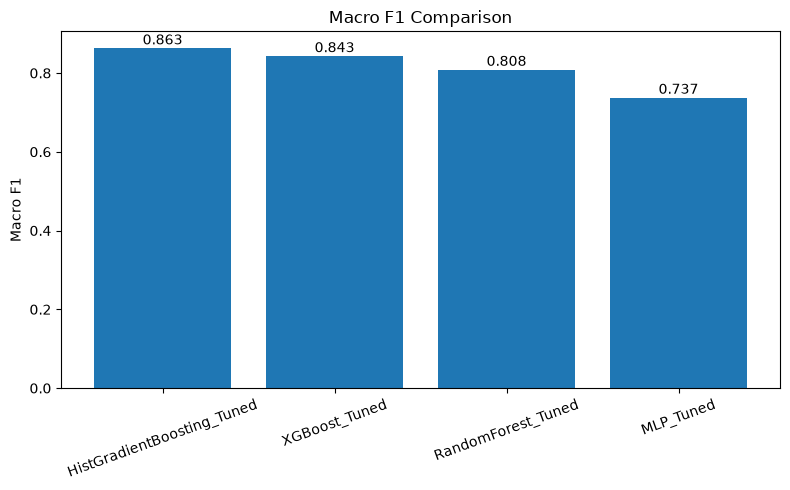

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Macro F1"])
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1")
plt.xticks(rotation=20)
for i, v in enumerate(comparison["Macro F1"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "macro_f1_comparison.png", dpi=200)
plt.show()

## 4. Precision / Recall / F1 (grouped) + Heatmap

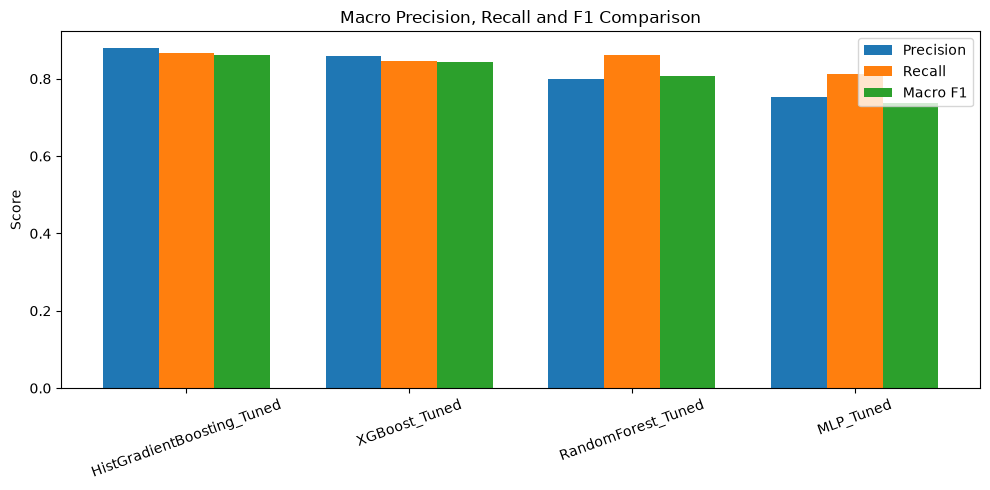

In [22]:
x = np.arange(len(comparison))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, comparison["Macro Precision"], width, label="Precision")
plt.bar(x, comparison["Macro Recall"], width, label="Recall")
plt.bar(x + width, comparison["Macro F1"], width, label="Macro F1")
plt.xticks(x, comparison["Model"], rotation=20)
plt.ylabel("Score")
plt.title("Macro Precision, Recall and F1 Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "precision_recall_f1_comparison.png", dpi=200)
plt.show()

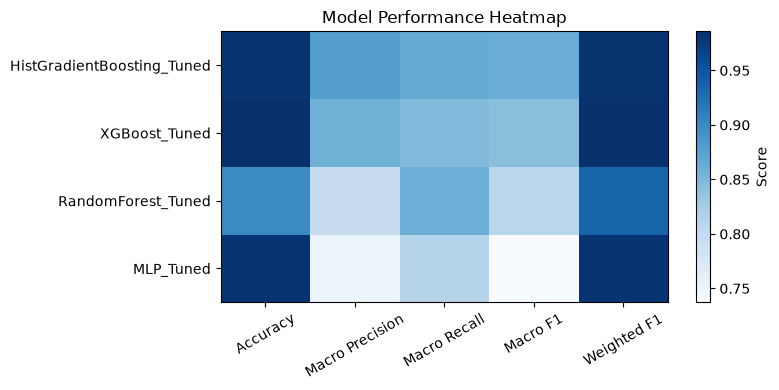

In [23]:
metrics_cols = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
heatmap_data = comparison.set_index("Model")[metrics_cols]

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_data, aspect="auto", cmap="Blues")
plt.xticks(range(len(metrics_cols)), metrics_cols, rotation=30)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label="Score")
plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "performance_heatmap.png", dpi=200)
plt.show()

## 5. Train vs. Test Gap (Overfitting Check)

Pulls together the train/test gap you've already computed at the end of notebooks 04 and 06,
so it's visible alongside everything else in one place. If either notebook's gap cell hasn't
been run/saved yet, this simply skips that source.

In [24]:
gap_path = TABLES_PATH / "train_vs_test_gap.csv"
if gap_path.exists():
    train_vs_test = pd.read_csv(gap_path)
    train_vs_test.to_csv(TABLES_PATH / "train_vs_test_gap.csv", index=False)  # re-save, no-op if unchanged
    train_vs_test
else:
    print(f"{gap_path.name} not found -- run the train/test gap cell in notebook 04 first.")
    train_vs_test = None
train_vs_test

,Model,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Accuracy Gap,Macro F1 Gap
0,RandomForest_Tuned,0.969477,0.899091,0.967747,0.808213,0.070386,0.159534
1,HistGradientBoosting_Tuned,0.976146,0.980299,0.964668,0.862697,-0.004153,0.101970
2,XGBoost_Tuned,0.971134,0.985870,0.942379,0.842936,-0.014737,0.099443


## 6. Rare-Class Performance

Overall accuracy is dominated by common classes like Benign. This isolates performance on the classes that matter most for a security use case but are hardest to learn: the ones with very few real samples.

In [25]:
RARE_CLASSES = [
    "SQL Injection", "Brute Force -XSS", "Brute Force -Web",
    "DoS attacks-Slowloris", "DoS attacks-SlowHTTPTest",
    "DDOS attack-LOIC-UDP", "DoS attacks-GoldenEye", "Infilteration",
]

report_files = sorted(MODELS_PATH.glob("*_classification_report.csv"))
print(f"Found {len(report_files)} classification reports:")
for f in report_files:
    print(" -", f.name)

per_class_f1 = {}
per_class_recall = {}

for f in report_files:
    model_name = f.stem.replace("_classification_report", "")
    report = pd.read_csv(f, index_col=0)

    # rows are class labels (as strings of the encoded id) plus accuracy/macro avg/weighted avg
    valid_rows = [str(label_to_id[c]) for c in RARE_CLASSES if str(label_to_id[c]) in report.index]
    report = report.loc[valid_rows]
    report.index = report.index.astype(int).map(id_to_label)

    per_class_f1[model_name] = report["f1-score"]
    per_class_recall[model_name] = report["recall"]

f1_comparison = pd.DataFrame(per_class_f1).reindex(RARE_CLASSES)
recall_comparison = pd.DataFrame(per_class_recall).reindex(RARE_CLASSES)

f1_comparison.to_csv(TABLES_PATH / "rare_class_f1_comparison.csv")
recall_comparison.to_csv(TABLES_PATH / "rare_class_recall_comparison.csv")

print("\nF1-score on rare classes, by model:")
f1_comparison.round(3)

Found 4 classification reports:
 - HistGradientBoosting_Tuned_classification_report.csv
 - MLP_Tuned_classification_report.csv
 - RandomForest_Tuned_classification_report.csv
 - XGBoost_Tuned_classification_report.csv

F1-score on rare classes, by model:


,HistGradientBoosting_Tuned,MLP_Tuned,RandomForest_Tuned,XGBoost_Tuned
SQL Injection,0.500,0.040,0.444,0.417
Brute Force -XSS,0.957,0.487,0.777,0.956
Brute Force -Web,0.803,0.467,0.614,0.736
DoS attacks-Slowloris,0.985,0.859,0.962,0.977
DoS attacks-SlowHTTPTest,0.604,0.563,0.497,0.582
DDOS attack-LOIC-UDP,0.980,0.984,0.984,0.983
DoS attacks-GoldenEye,0.995,0.992,0.992,0.990
Infilteration,0.294,0.256,0.096,0.271


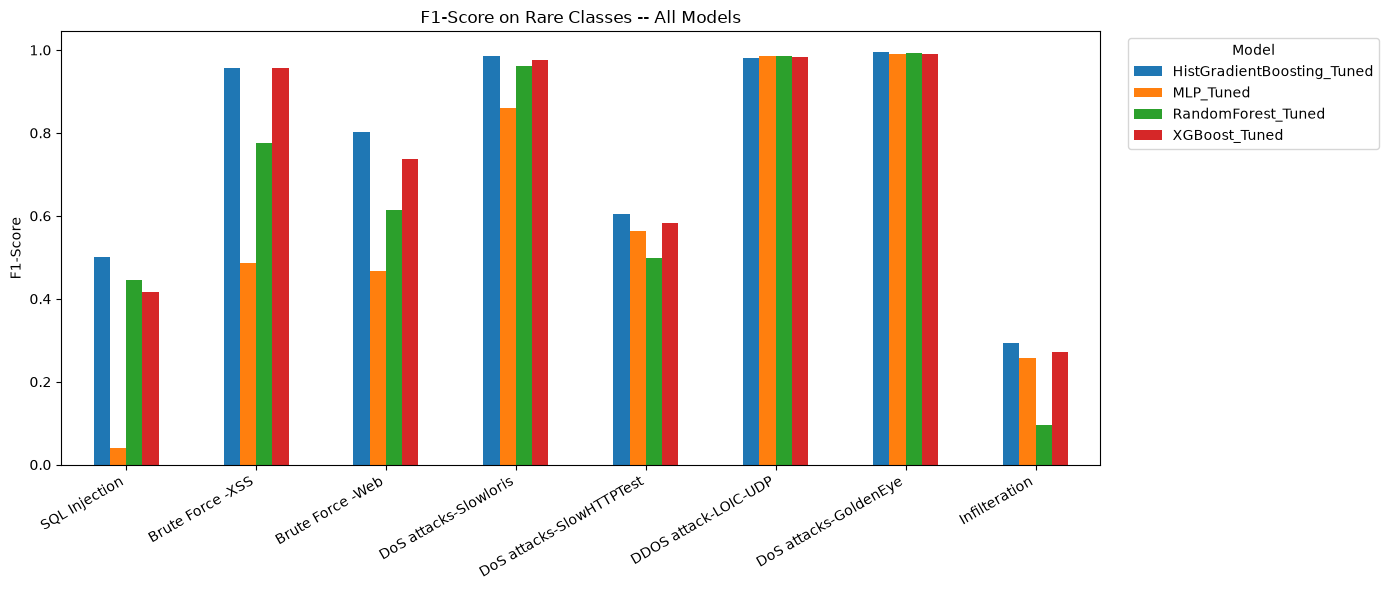

In [26]:
f1_comparison.plot(kind="bar", figsize=(14, 6))
plt.title("F1-Score on Rare Classes -- All Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "rare_class_f1_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Class Distribution Before vs. After Augmentation

In [27]:
train_before = pd.read_parquet(PROCESSED_DATA_PATH / "train_selected.parquet")
train_after = pd.read_parquet(PROCESSED_DATA_PATH / "balanced_train_selected.parquet")

before = train_before["Label"].value_counts().sort_index()
after = train_after["Label"].value_counts().sort_index()

class_dist = pd.DataFrame({"Before CTGAN": before, "After CTGAN": after}).fillna(0)
class_dist.index = class_dist.index.map(id_to_label)  # show attack names, not just encoded ids
class_dist.index.name = "Attack Name"

class_dist.to_csv(TABLES_PATH / "class_distribution_before_after_CTGAN.csv")
class_dist

,Before CTGAN,After CTGAN
Attack Name,,
Benign,680805,100000
Bot,14293,14293
Brute Force -Web,489,10000
Brute Force -XSS,184,10000
DDOS attack-HOIC,33844,33844
DDOS attack-LOIC-UDP,1384,5536
DDoS attacks-LOIC-HTTP,29171,29171
DoS attacks-GoldenEye,2099,8396
DoS attacks-Hulk,22017,22017


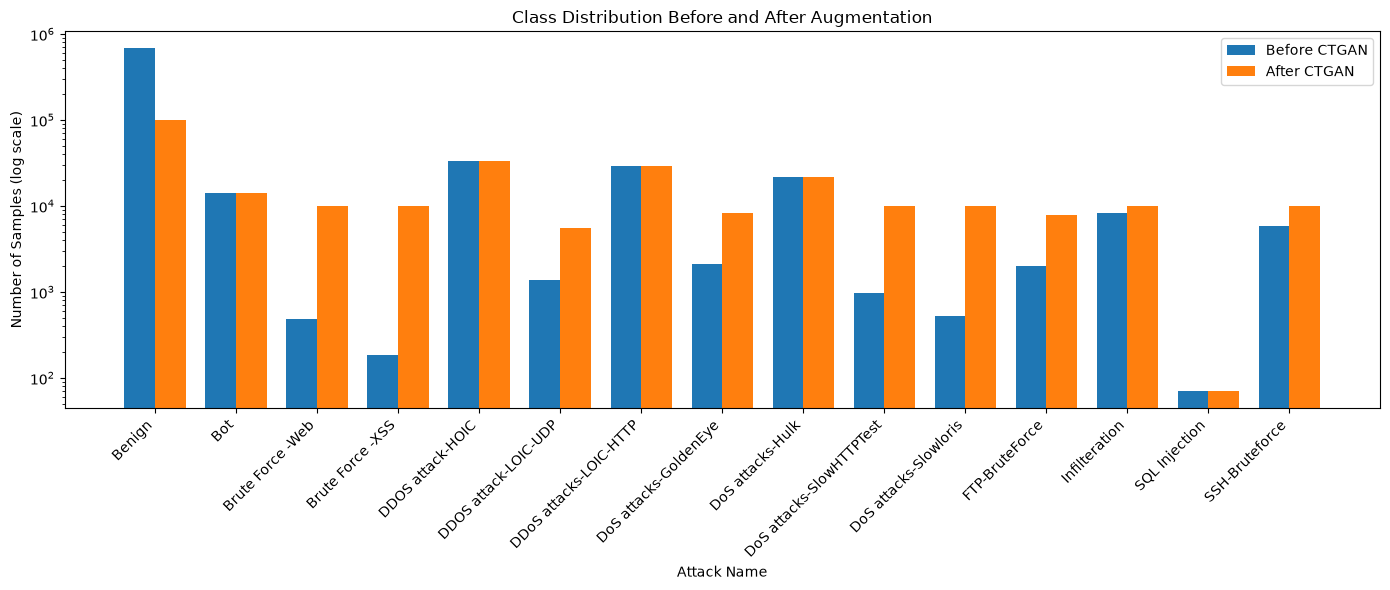

In [28]:
x = np.arange(len(class_dist))
width = 0.38

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, class_dist["Before CTGAN"], width, label="Before CTGAN")
plt.bar(x + width/2, class_dist["After CTGAN"], width, label="After CTGAN")
plt.yscale("log")
plt.xticks(x, class_dist.index, rotation=45, ha="right")
plt.ylabel("Number of Samples (log scale)")
plt.xlabel("Attack Name")
plt.title("Class Distribution Before and After Augmentation")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "class_distribution_before_after_CTGAN.png", dpi=200)
plt.show()

## 8. Top Mutual Information Features

> **Path note:** `03_Data_Preparation_for_CTGAN.ipynb` currently saves
> `mutual_information_scores.csv` directly under `Results/`, not `Results/Tables/` like everything
> else. This cell reads from the actual location rather than assuming consistency -- worth
> fixing in notebook 03 later so every output lives under `Results/Tables/` uniformly.

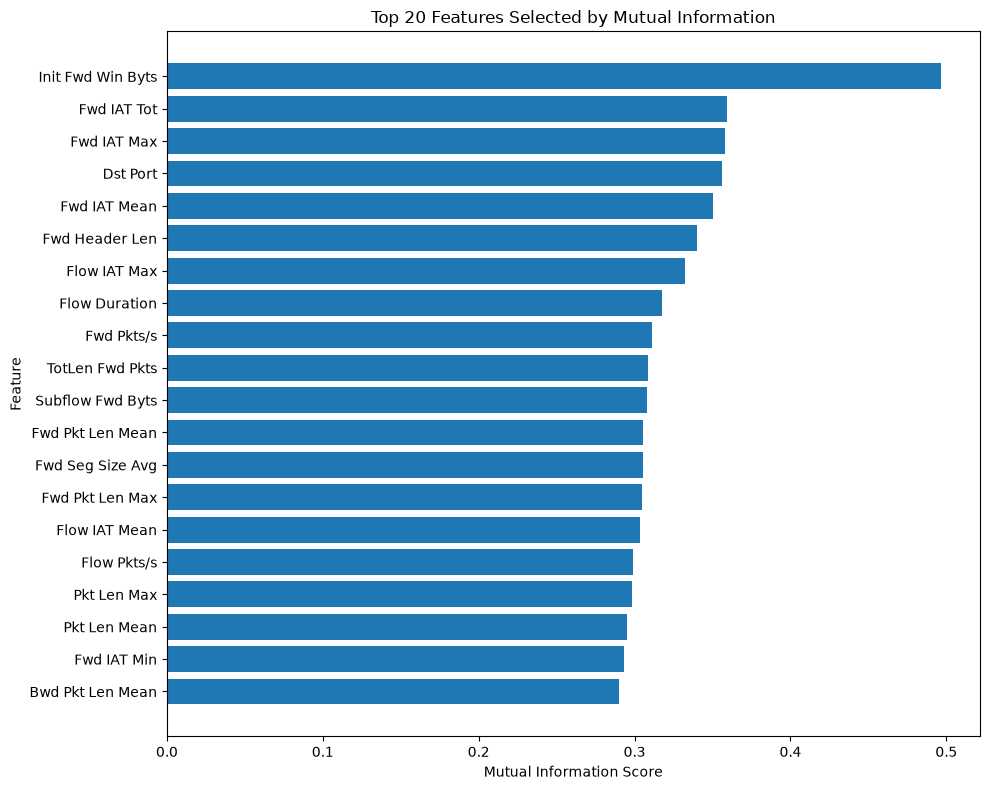

In [29]:
mi_path = RESULTS_PATH / "mutual_information_scores.csv"

if mi_path.exists():
    mi = pd.read_csv(mi_path).sort_values("MI Score", ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    plt.barh(mi["Feature"][::-1], mi["MI Score"][::-1])
    plt.xlabel("Mutual Information Score")
    plt.ylabel("Feature")
    plt.title("Top 20 Features Selected by Mutual Information")
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / "top20_mutual_information.png", dpi=200)
    plt.show()
else:
    print(f"Skipped: {mi_path} not found. Run 03_Data_Preparation_for_CTGAN.ipynb first.")

---
**Final report artifacts (under `Results/`):**
- `Tables/model_comparison.csv`, `Tables/rare_class_f1_comparison.csv`,
  `Tables/rare_class_recall_comparison.csv`, `Tables/class_distribution_before_after_CTGAN.csv`
- `Figures/accuracy_comparison.png`, `macro_f1_comparison.png`, `precision_recall_f1_comparison.png`,
  `performance_heatmap.png`, `rare_class_f1_comparison.png`,
  `class_distribution_before_after_CTGAN.png`, `top20_mutual_information.png`

Your Streamlit dashboard (`app.py`) reads all of these live -- just refresh the browser tab after
running this notebook to see the update.